In [2]:
import pandas as pd
import numpy as np
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
os.getcwd()
# 'C:\\Users\\gcart'

# set wooking directory
os.chdir('E:\\docs\\book_reviews\\manning\\solve_any_data_analysis_problem\\notebooks')
os.getcwd()
# 'C:\\Users\\gcart'


'E:\\docs\\book_reviews\\manning\\solve_any_data_analysis_problem\\notebooks'

In [4]:
 
traffic = pd.read_csv("dft_traffic_counts_raw_counts.csv.gz")
print(traffic.shape)
traffic.head()

(4815504, 35)


,Count_point_id,Direction_of_travel,Year,Count_date,hour,Region_id,Region_name,Region_ons_code,Local_authority_id,Local_authority_name,...,Buses_and_coaches,LGVs,HGVs_2_rigid_axle,HGVs_3_rigid_axle,HGVs_4_or_more_rigid_axle,HGVs_3_or_4_articulated_axle,HGVs_5_articulated_axle,HGVs_6_articulated_axle,All_HGVs,All_motor_vehicles
0,749,E,2014,2014-06-25 00:00:00,7,3,Scotland,S92000003,39,East Ayrshire,...,5.0,31,15.0,4.0,4.0,4.0,13,12.0,52.0,935.0
1,749,E,2014,2014-06-25 00:00:00,8,3,Scotland,S92000003,39,East Ayrshire,...,7.0,103,29.0,3.0,2.0,7.0,18,20.0,79.0,1102.0
2,749,E,2014,2014-06-25 00:00:00,9,3,Scotland,S92000003,39,East Ayrshire,...,14.0,88,21.0,3.0,5.0,9.0,17,19.0,74.0,773.0
3,749,E,2014,2014-06-25 00:00:00,10,3,Scotland,S92000003,39,East Ayrshire,...,8.0,90,31.0,6.0,10.0,7.0,18,17.0,89.0,778.0
4,749,E,2014,2014-06-25 00:00:00,11,3,Scotland,S92000003,39,East Ayrshire,...,18.0,75,38.0,2.0,2.0,3.0,16,24.0,85.0,875.0


In [5]:
# look at missing data

traffic.isnull().sum()

Count_point_id                        0
Direction_of_travel                   0
Year                                  0
Count_date                            0
hour                                  0
Region_id                             0
Region_name                           0
Region_ons_code                       0
Local_authority_id                    0
Local_authority_name                  0
Local_authority_code                  0
Road_name                             0
Road_category                         0
Road_type                             0
Start_junction_road_name        2634972
End_junction_road_name          2634912
Easting                               0
Northing                              0
Latitude                              0
Longitude                             0
Link_length_km                  2632824
Link_length_miles               2632824
Pedal_cycles                          0
Two_wheeled_motor_vehicles            0
Cars_and_taxis                        1


In [6]:
# There is a small number of measurements missing, which we will assume can be filled with zeros with the following code.

measurement_cols = [
    'Pedal_cycles', 'Two_wheeled_motor_vehicles',
    'Cars_and_taxis', 'Buses_and_coaches',
    'LGVs', 'HGVs_2_rigid_axle', 'HGVs_3_rigid_axle',
    'HGVs_4_or_more_rigid_axle', 'HGVs_3_or_4_articulated_axle',
    'HGVs_5_articulated_axle', 'HGVs_6_articulated_axle',
    'All_HGVs', 'All_motor_vehicles'
]
 
for col in measurement_cols:
    traffic[col] = traffic[col].fillna(0)

In [7]:
# nvestigate what regions are covered by the data by inspecting the Region_name column

traffic["Region_name"].value_counts()


South East                  770532
North West                  562092
East of England             534120
South West                  478668
West Midlands               467604
Yorkshire and the Humber    413616
London                      393588
East Midlands               384516
Scotland                    298368
Wales                       286476
North East                  225924
Name: Region_name, dtype: int64

In [8]:
# ount the unique combinations and verify that they match the row count

len(traffic[["Count_point_id", "Year", "Count_date", "hour"]].drop_duplicates())

2435120

In [12]:
# add Direction_of_travel to the key to see if it matches the number of rows

len(traffic[["Count_point_id", "Year", "Count_date", "hour", "Direction_of_travel"]].drop_duplicates())

4815480

In [13]:
# find duplicate keys

duplicate_groups = (
    traffic
    .groupby(["Count_point_id", "Year", "Count_date", "hour", "Direction_of_travel"])
    .size()
    .loc[lambda x: x > 1]
)
 
duplicate_groups

Count_point_id  Year  Count_date           hour  Direction_of_travel
7845            2014  2014-09-03 00:00:00  7     W                      2
                                           8     W                      2
                                           9     W                      2
                                           10    W                      2
                                           11    W                      2
                                           12    W                      2
                                           13    W                      2
                                           14    W                      2
                                           15    W                      2
                                           16    W                      2
                                           17    W                      2
                                           18    W                      2
77043           2003  2003-06-18 00:00:00  

In [14]:
# take one of the keys as an example and looking at which values the duplicate rows differ in.

# find a specific example of a duplicate
example_dupes = (
  traffic[
    (traffic["Count_point_id"] == 7845)
      & (traffic["Count_date"] == "2014-09-03 00:00:00")
      & (traffic["hour"] == 7)
      & (traffic["Direction_of_travel"] == "W")
  ]
)
 
(
  # use the shift method to check if values are equal in both rows
  example_dupes
  .eq(example_dupes.shift(-1))
  .iloc[0]
  .loc[lambda x: x == False]
)

Two_wheeled_motor_vehicles      False
Cars_and_taxis                  False
Buses_and_coaches               False
LGVs                            False
HGVs_2_rigid_axle               False
HGVs_3_rigid_axle               False
HGVs_4_or_more_rigid_axle       False
HGVs_3_or_4_articulated_axle    False
HGVs_5_articulated_axle         False
HGVs_6_articulated_axle         False
All_HGVs                        False
All_motor_vehicles              False
Name: 24372, dtype: bool

In [15]:
# look at the specific measurements to determine how different

(
  example_dupes[[
    'Two_wheeled_motor_vehicles', 'Cars_and_taxis', 'Buses_and_coaches',
    'LGVs', 'HGVs_2_rigid_axle', 'HGVs_3_rigid_axle',
    'HGVs_4_or_more_rigid_axle', 'HGVs_3_or_4_articulated_axle',
    'HGVs_5_articulated_axle', 'HGVs_6_articulated_axle', 'All_HGVs',
    'All_motor_vehicles']]
  .transpose()
)

,24372,24384
Two_wheeled_motor_vehicles,9.0,8.0
Cars_and_taxis,1567.0,1115.0
Buses_and_coaches,7.0,9.0
LGVs,185.0,168.0
HGVs_2_rigid_axle,30.0,29.0
HGVs_3_rigid_axle,5.0,6.0
HGVs_4_or_more_rigid_axle,5.0,1.0
HGVs_3_or_4_articulated_axle,6.0,1.0
HGVs_5_articulated_axle,2.0,4.0
HGVs_6_articulated_axle,10.0,13.0


In [16]:
# check for missing values before creating negative value as a placeholder

print(traffic["Link_length_km"].min(),
      traffic["Link_length_miles"].min())

0.1 0.06


In [17]:
'''
    Replace missing values with placeholders
    Group by all columns except the measurements
    Within each group, which are mostly one row each, average the measurement values
    In the grouped and aggregated dataset, replace placeholders with missing data again
'''

TEXT_PLACEHOLDER = "PLACEHOLDER"
NUMBER_PLACEHOLDER = -9999
 
group_cols = [
  'Count_point_id', 'Direction_of_travel', 'Year', 'Count_date', 'hour',
  'Region_id', 'Region_name', 'Region_ons_code', 'Local_authority_id',
  'Local_authority_name', 'Local_authority_code', 'Road_name',
  'Road_category', 'Road_type', 'Start_junction_road_name',
  'End_junction_road_name', 'Easting', 'Northing', 'Latitude',
  'Longitude', 'Link_length_km', 'Link_length_miles'
]
 
traffic_deduped = (
  traffic
  .assign(
    Start_junction_road_name = lambda df_: df_["Start_junction_road_name"].fillna(TEXT_PLACEHOLDER),
    End_junction_road_name   = lambda df_: df_["End_junction_road_name"].fillna(TEXT_PLACEHOLDER),
    Link_length_km           = lambda df_: df_["Link_length_km"].fillna(NUMBER_PLACEHOLDER),
    Link_length_miles        = lambda df_: df_["Link_length_miles"].fillna(NUMBER_PLACEHOLDER)
  )
  .groupby(group_cols)
  .mean(numeric_only=True)
  .reset_index()
  .assign(
    Start_junction_road_name = lambda df_: df_["Start_junction_road_name"].replace(TEXT_PLACEHOLDER, np.nan),
    End_junction_road_name   = lambda df_: df_["End_junction_road_name"].replace(TEXT_PLACEHOLDER, np.nan),
    Link_length_km           = lambda df_: df_["Link_length_km"].replace(NUMBER_PLACEHOLDER, np.nan),
    Link_length_miles        = lambda df_: df_["Link_length_miles"].replace(NUMBER_PLACEHOLDER, np.nan)
  )
)
 
print(traffic.shape, traffic_deduped.shape)

(4815504, 35) (4815480, 35)


In [18]:
# understand the date range of the data after we convert the date column to be the right type

traffic["Count_date"] = pd.to_datetime(traffic["Count_date"], format="%Y-%m-%d %H:%M:%S")
traffic["Count_date"].agg(["min", "max"])


min   2000-03-17
max   2022-11-02
Name: Count_date, dtype: datetime64[ns]

In [19]:
# calculate the first and last date per location, calculate the difference, and investigate the distribution of this difference number. 
# This will tell us how long each location-specific time series is

coverage_by_point = (
    traffic
    .groupby("Count_point_id")
    ["Count_date"]
    .agg(["min", "max"])
    .assign(coverage_years = lambda x: (x["max"] - x["min"]).dt.days / 365)
    .sort_values("coverage_years", ascending=False)
)
 
coverage_by_point


,min,max,coverage_years
Count_point_id,,,
36583,2000-03-24,2022-10-21,22.591781
57775,2000-03-22,2022-10-13,22.575342
60024,2000-03-21,2022-10-11,22.572603
70222,2000-03-17,2022-10-05,22.567123
38544,2000-03-17,2022-10-03,22.561644
...,...,...,...
940862,2008-10-02,2008-10-02,0.000000
940867,2009-03-20,2009-03-20,0.000000
940868,2008-04-14,2008-04-14,0.000000


In [20]:
# the distribution of zero-coverage locations across regions

zero_location_ids = coverage_by_point[coverage_by_point["coverage_years"] == 0].index
 
zero_locations = (
    traffic[traffic["Count_point_id"].isin(zero_location_ids)]
    .drop_duplicates("Count_point_id")
)
 
print(len(zero_locations))
zero_locations["Region_name"].value_counts()

13460


South East                  1906
East of England             1724
South West                  1656
North West                  1571
Yorkshire and the Humber    1262
West Midlands               1256
East Midlands               1089
Scotland                     942
London                       829
North East                   713
Wales                        512
Name: Region_name, dtype: int64

In [22]:
# calculate these as a percentage of the total number of locations in each region to get a fair comparison

location_sizes = (
    traffic
    .groupby("Region_name")
    ["Count_point_id"]
    .nunique()
)

print(location_sizes)

Region_name
East Midlands               3405
East of England             4666
London                      3329
North East                  2022
North West                  5063
Scotland                    3376
South East                  6097
South West                  4451
Wales                       2338
West Midlands               4132
Yorkshire and the Humber    3642
Name: Count_point_id, dtype: int64


In [23]:
# joins the two tables together

(
    location_sizes
    .reset_index()
    .merge(
        zero_locations["Region_name"]
            .value_counts()
            .reset_index(name="count")
            .rename(columns={"index": "Region_name"}),
        on="Region_name"
    )
    .rename(columns={
        "Count_point_id": "total_points",
        "count": "number_of_zeros"
    })
    .assign(pct_zeros = lambda x: x["number_of_zeros"] / x["total_points"])
)

,Region_name,total_points,number_of_zeros,pct_zeros
0,East Midlands,3405,1089,0.319824
1,East of England,4666,1724,0.369481
2,London,3329,829,0.249024
3,North East,2022,713,0.352621
4,North West,5063,1571,0.310290
5,Scotland,3376,942,0.279028
6,South East,6097,1906,0.312613
7,South West,4451,1656,0.372051
8,Wales,2338,512,0.218991
9,West Midlands,4132,1256,0.303969


In [24]:
# look at the number of data points per location per date to give us an idea of whether there might be continuity problems

points_and_dates = (
    traffic
    .groupby(["Count_point_id", "Count_date"])
    .size()
    .reset_index()
    .sort_values(["Count_point_id", "Count_date"])
)
 
points_and_dates.head()

,Count_point_id,Count_date,0
0,51,2004-05-21,24
1,51,2012-10-17,24
2,51,2020-10-02,24
3,52,2002-09-24,24
4,52,2011-10-04,24


In [25]:
# heck how many unique values there are for the Year column in each location

num_years_by_point = (
    traffic
    .groupby("Count_point_id")
    ["Year"]
    .nunique()
    .loc[lambda x: x > 10]
    .sort_values(ascending=False)
)
 
num_years_by_point

Count_point_id
26010     23
46010     23
46008     23
16008     23
56047     23
          ..
943254    11
943258    11
943260    11
943262    11
942247    11
Name: Year, Length: 4959, dtype: int64

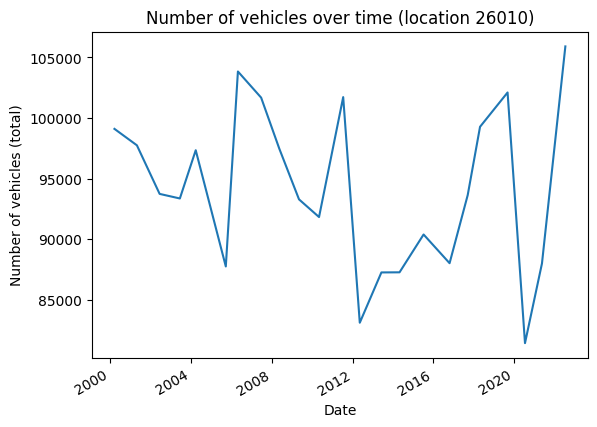

In [26]:
# look at the time series for the first of those locations to get a sense of what a complete time series looks like in our data

fig, axis = plt.subplots()
 
LOCATION_ID = "26010"
 
(
    traffic
    .query(f"Count_point_id == {LOCATION_ID}")
    .groupby("Count_date")
    ["All_motor_vehicles"]
    .sum()
    .plot(ax=axis)
)
 
axis.set(
    title=f"Number of vehicles over time (location {LOCATION_ID})",
    xlabel="Date",
    ylabel="Number of vehicles (total)"
)
 
plt.show()

In [27]:
# filter our location list to only the time series that have no gaps. To do this, we will ensure our data is sorted and create a temporary 
# column to capture the year of the previous row so that we can find instances where the gap between a row and the previous one is more than a year

long_count_points = num_years_by_point.index
 
gaps = (
    traffic
    .query("Count_point_id in @long_count_points")
    [["Count_point_id", "Year"]]
    .drop_duplicates()
    .sort_values(["Count_point_id", "Year"])
    .assign(
        prev_year= lambda x: x["Year"].shift(),
        diff= lambda x: x["Year"] - x["prev_year"]
    )
)
 
gaps.head()

,Count_point_id,Year,prev_year,diff
2702896,501,2000,NaN,NaN
2526432,501,2001,2000.0,1.0
2320148,501,2002,2001.0,1.0
2642988,501,2004,2002.0,2.0
1444969,501,2006,2004.0,2.0


In [28]:
# To make sure we filter gaps properly, we also need to track the location ID of the previous column so that when we encounter a gap greater 
# than one year, we also check whether the location ID is still the same. 

gaps = (
    gaps
    .assign(
        prev_id= lambda x: x["Count_point_id"].shift()
    )
    .query("diff > 1 and Count_point_id == prev_id")
)
 
gaps.head()

,Count_point_id,Year,prev_year,diff,prev_id
2642988,501,2004,2002.0,2.0,501.0
1444969,501,2006,2004.0,2.0,501.0
528811,501,2009,2006.0,3.0,501.0
4054701,501,2019,2017.0,2.0,501.0
4791625,501,2022,2020.0,2.0,501.0


In [29]:
# use this gaps DataFrame to find all the unique location IDs that we want to exclude from our final time series data

gap_ids = gaps["Count_point_id"].unique()
 
all_time_series_raw = (
    traffic
    .query("Count_point_id in @long_count_points \
    and Count_point_id not in @gap_ids")
)
 
all_time_series_raw.head()



,Count_point_id,Direction_of_travel,Year,Count_date,hour,Region_id,Region_name,Region_ons_code,Local_authority_id,Local_authority_name,...,Buses_and_coaches,LGVs,HGVs_2_rigid_axle,HGVs_3_rigid_axle,HGVs_4_or_more_rigid_axle,HGVs_3_or_4_articulated_axle,HGVs_5_articulated_axle,HGVs_6_articulated_axle,All_HGVs,All_motor_vehicles
2488,931855,E,2016,2016-06-06,7,3,Scotland,S92000003,206,East Renfrewshire,...,4.0,33,1.0,0.0,0.0,0.0,0,0.0,1.0,233.0
2489,931855,E,2016,2016-06-06,8,3,Scotland,S92000003,206,East Renfrewshire,...,12.0,30,0.0,3.0,3.0,0.0,1,0.0,7.0,437.0
2490,931855,E,2016,2016-06-06,9,3,Scotland,S92000003,206,East Renfrewshire,...,4.0,21,0.0,1.0,3.0,0.0,0,1.0,5.0,250.0
2491,931855,E,2016,2016-06-06,10,3,Scotland,S92000003,206,East Renfrewshire,...,2.0,36,2.0,0.0,0.0,0.0,0,0.0,2.0,261.0
2492,931855,E,2016,2016-06-06,11,3,Scotland,S92000003,206,East Renfrewshire,...,2.0,43,1.0,2.0,1.0,0.0,0,0.0,4.0,282.0


In [30]:
# aggregate this to actually be a time series summarized at a location level so we better understand how much data we are left with

all_time_series = (
    all_time_series_raw
    .groupby(["Count_point_id", "Count_date"])
    ["All_motor_vehicles"]
    .sum()
    .reset_index()
)
 
print(all_time_series["Count_point_id"].nunique())
all_time_series.head()

1419


,Count_point_id,Count_date,All_motor_vehicles
0,6003,2000-03-31,87479.0
1,6003,2001-06-25,74103.0
2,6003,2002-05-21,72377.0
3,6003,2003-06-05,91505.0
4,6003,2004-06-16,90564.0


In [31]:
# What days of the week is the data spread across? 

(
    all_time_series_raw[["Count_date"]]
    .drop_duplicates()
    ["Count_date"]
    .dt.weekday
    .value_counts(normalize=True)
    .sort_index()
)

0    0.186194
1    0.203293
2    0.205193
3    0.200127
4    0.205193
Name: Count_date, dtype: float64

In [32]:
# counts the number of unique months for each location point, only keeping instances where that number is 1, i.e., locations
# where we’ve only ever encountered the same month

same_month_time_series = (
    all_time_series
    .assign(month=lambda x: x["Count_date"].dt.month)
    .groupby("Count_point_id")
    ["month"]
    .nunique()
    .loc[lambda x: x == 1]
)
 
print(len(same_month_time_series))
 
same_month_time_series.head()

691


Count_point_id
900056    1
919150    1
930188    1
931832    1
931837    1
Name: month, dtype: int64

In [33]:
# spot check that the time series associated with these location IDs do indeed only contain the same month

all_time_series[all_time_series["Count_point_id"] == 900056]

,Count_point_id,Count_date,All_motor_vehicles
324,900056,2007-05-14,10097.0
325,900056,2008-05-12,10278.0
326,900056,2009-05-11,10367.0
327,900056,2010-05-10,8705.0
328,900056,2011-05-16,7769.0
329,900056,2012-05-14,8435.0
330,900056,2013-05-13,8107.0
331,900056,2014-05-12,8798.0
332,900056,2015-05-11,8896.0
333,900056,2016-05-09,7508.0


In [34]:
# Exporting only complete time series data

ids_to_export = same_month_time_series.index
 
(
    traffic
    .query("Count_point_id in @ids_to_export")
    .to_parquet("time_series.parquet.gz", compression="gzip")
)